# Notebook 07B – Final Model Analysis and Selection

This notebook performs the final analysis of models evaluated in Notebook 07A.

Unlike Notebook 07A, this notebook does not retrain models. It loads the saved validation results and performs:

- Final performance visualization
- Per-well performance analysis
- Residual analysis
- Statistical model comparison
- Ensemble evaluation
- Final model selection
- Artifact saving

This separation allows the analysis to be rerun quickly without repeating expensive model training.

### 1. Import Libraries

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

### 2. Configure Project Paths

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"

NOTEBOOK_07A_RESULTS_DIR = (
    RESULTS_DIR
    / "notebook_07"
)

NOTEBOOK_07B_RESULTS_DIR = (
    RESULTS_DIR
    / "notebook_07b"
)

FIGURES_DIR = (
    NOTEBOOK_07B_RESULTS_DIR
    / "figures"
)

TABLES_DIR = (
    NOTEBOOK_07B_RESULTS_DIR
    / "tables"
)

METADATA_DIR = (
    NOTEBOOK_07B_RESULTS_DIR
    / "metadata"
)

for directory in [
    NOTEBOOK_07B_RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    METADATA_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)
print("Notebook 07A results:", NOTEBOOK_07A_RESULTS_DIR)
print("Notebook 07B results:", NOTEBOOK_07B_RESULTS_DIR)

Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Notebook 07A results: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_07
Notebook 07B results: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_07b


### 3. Inspect Notebook 07A Artifacts

Before loading the evaluation results, this section inspects the files saved by Notebook 07A.

This ensures that all required comparison tables, fold metrics, and out-of-fold predictions are available for analysis.

In [3]:
if not NOTEBOOK_07A_RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Notebook 07A results directory does not exist: "
        f"{NOTEBOOK_07A_RESULTS_DIR}"
    )

available_files = sorted(
    path
    for path in NOTEBOOK_07A_RESULTS_DIR.rglob("*")
    if path.is_file()
)

print(
    f"Found {len(available_files)} files "
    f"inside Notebook 07A results."
)

for path in available_files:
    print(path.relative_to(NOTEBOOK_07A_RESULTS_DIR))

Found 18 files inside Notebook 07A results.
all_models_groupkfold_fold_metrics.csv
comparison_plots\optimization_trial_mae.png
comparison_plots\optimization_trial_rmse.png
extra_trees_optimized_groupkfold_fold_metrics.csv
extra_trees_optimized_groupkfold_predictions.parquet
extra_trees_optimized_groupkfold_summary.csv
final_candidate_registry.csv
final_groupkfold_model_comparison.csv
linear_regression_groupkfold_fold_metrics.csv
linear_regression_groupkfold_predictions.parquet
linear_regression_groupkfold_summary.csv
random_forest_groupkfold_fold_metrics.csv
random_forest_groupkfold_predictions.parquet
random_forest_groupkfold_summary.csv
top_two_models_comparison.csv
xgboost_optimized_groupkfold_fold_metrics.csv
xgboost_optimized_groupkfold_predictions.parquet
xgboost_optimized_groupkfold_summary.csv


### 5. Load Final Model Comparison

This section loads the unified GroupKFold comparison table generated in Notebook 07A.

The table contains the final performance metrics for all candidate models evaluated under the same validation protocol.

In [4]:
FINAL_COMPARISON_PATH = (
    NOTEBOOK_07A_RESULTS_DIR
    / "final_groupkfold_model_comparison.csv"
)

final_model_comparison_df = pd.read_csv(
    FINAL_COMPARISON_PATH
)

print(
    f"Loaded final comparison table with "
    f"{len(final_model_comparison_df)} models."
)

display(final_model_comparison_df)

Loaded final comparison table with 4 models.


,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells,rmse_rank,mae_rank,stability_rank,final_position,rmse_improvement_vs_linear,rmse_improvement_pct_vs_linear,mae_improvement_vs_linear,mae_improvement_pct_vs_linear
0,Extra Trees Optimized,5-Fold GroupKFold,83.5860,37.7493,82.3172,16.1868,37.7475,4.9516,864.2304,27.0497,943.9294,5092255,773,1,1,2,1,32.0538,27.7187,46.0905,54.9745
1,XGBoost Optimized,5-Fold GroupKFold,93.4311,46.2798,91.9583,18.4275,46.2782,4.5942,"1,402.4669",38.7495,"1,492.7247",5092255,773,2,2,3,2,22.2087,19.2051,37.5600,44.7997
2,Random Forest,5-Fold GroupKFold,105.0019,48.5106,103.6866,18.4787,48.5077,4.7310,"2,809.8988",14.5258,"2,868.5773",5092255,773,3,3,4,3,10.6380,9.1992,35.3293,42.1390
3,Linear Regression,5-Fold GroupKFold,115.6399,83.8398,115.0839,12.7728,83.8426,5.6276,148.6929,4.0001,202.7103,5092255,773,4,4,1,4,0.0000,0.0000,0.0000,0.0000


### 6. Load Combined Fold Metrics

Fold-level metrics are loaded to analyse validation stability and compare model performance across individual GroupKFold splits.

These results will later support visual comparisons and statistical testing.

In [5]:
ALL_FOLD_METRICS_PATH = (
    NOTEBOOK_07A_RESULTS_DIR
    / "all_models_groupkfold_fold_metrics.csv"
)

all_fold_metrics_df = pd.read_csv(
    ALL_FOLD_METRICS_PATH
)

print(
    f"Loaded {len(all_fold_metrics_df)} "
    f"fold-level metric records."
)

display(all_fold_metrics_df.head(10))

Loaded 20 fold-level metric records.


,model,fold,rmse,mae,training_seconds,prediction_seconds,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,Linear Regression,1,132.5732,82.7140,29.7006,0.8915,4075197,1017058,619,154,0
1,Linear Regression,2,120.2329,92.0290,38.4975,0.9330,4075198,1017057,619,154,0
2,Linear Regression,3,97.6116,76.2415,31.3882,1.0198,4073152,1019103,618,155,0
3,Linear Regression,4,113.3874,83.6333,27.1420,0.6069,4072802,1019453,618,155,0
4,Linear Regression,5,111.6145,84.5952,21.9646,0.5489,4072671,1019584,618,155,0
5,Random Forest,1,88.7585,43.0166,636.1881,3.4918,4075197,1017058,619,154,0
6,Random Forest,2,107.8943,47.9326,551.4029,2.6199,4075198,1017057,619,154,0
7,Random Forest,3,91.5380,47.6478,546.6478,2.8354,4073152,1019103,618,155,0
8,Random Forest,4,134.0447,56.1133,552.4978,2.8736,4072802,1019453,618,155,0
9,Random Forest,5,96.1974,47.8281,523.1621,2.7051,4072671,1019584,618,155,0


### 7. Load Out-of-Fold Predictions

Out-of-fold predictions are loaded for every candidate model.

These predictions were generated only for validation rows that were not used during the corresponding model training fold. Therefore, they provide an unbiased basis for residual analysis, per-well evaluation, and ensemble testing.

In [6]:
OOF_PREDICTION_FILES = {
    "Linear Regression": (
        NOTEBOOK_07A_RESULTS_DIR
        / "linear_regression_groupkfold_predictions.parquet"
    ),
    "Random Forest": (
        NOTEBOOK_07A_RESULTS_DIR
        / "random_forest_groupkfold_predictions.parquet"
    ),
    "Extra Trees Optimized": (
        NOTEBOOK_07A_RESULTS_DIR
        / "extra_trees_optimized_groupkfold_predictions.parquet"
    ),
    "XGBoost Optimized": (
        NOTEBOOK_07A_RESULTS_DIR
        / "xgboost_optimized_groupkfold_predictions.parquet"
    ),
}

oof_predictions = {}

for model_name, prediction_path in OOF_PREDICTION_FILES.items():

    if not prediction_path.exists():
        raise FileNotFoundError(
            f"Missing OOF prediction file for "
            f"{model_name}: {prediction_path}"
        )

    prediction_df = pd.read_parquet(
        prediction_path
    )

    oof_predictions[model_name] = prediction_df

    print(
        f"{model_name}: "
        f"{prediction_df.shape[0]:,} rows, "
        f"{prediction_df.shape[1]} columns"
    )

Linear Regression: 5,092,255 rows, 7 columns
Random Forest: 5,092,255 rows, 7 columns
Extra Trees Optimized: 5,092,255 rows, 7 columns
XGBoost Optimized: 5,092,255 rows, 7 columns


In [7]:
sample_model_name = "Extra Trees Optimized"

display(
    oof_predictions[
        sample_model_name
    ].head()
)

print(
    oof_predictions[
        sample_model_name
    ].columns.tolist()
)

,row_index,well_id,actual_tvt,predicted_tvt,fold,model,residual
0,0,000d7d20,"11,236.0200","11,246.6283",4,Extra Trees Optimized,-10.6083
1,1,000d7d20,"11,237.0500","11,247.6353",4,Extra Trees Optimized,-10.5853
2,2,000d7d20,"11,238.0900","11,248.6251",4,Extra Trees Optimized,-10.5351
3,3,000d7d20,"11,239.1200","11,250.8474",4,Extra Trees Optimized,-11.7274
4,4,000d7d20,"11,240.1500","11,255.4614",4,Extra Trees Optimized,-15.3114


['row_index', 'well_id', 'actual_tvt', 'predicted_tvt', 'fold', 'model', 'residual']


### 8. Validate Loaded Artifacts

Before beginning the final analysis, the loaded artifacts are validated for consistency.

The validation checks confirm that:

- Every expected model is available.
- Prediction tables are not empty.
- Required prediction columns exist.
- Each model contains the same validation observations.
- The comparison and fold-metric tables were loaded correctly.

In [8]:
EXPECTED_MODELS = [
    "Linear Regression",
    "Random Forest",
    "Extra Trees Optimized",
    "XGBoost Optimized",
]

assert not final_model_comparison_df.empty
assert not all_fold_metrics_df.empty

for model_name in EXPECTED_MODELS:

    assert model_name in oof_predictions, (
        f"Missing predictions for {model_name}"
    )

    assert not oof_predictions[model_name].empty, (
        f"Empty prediction table for {model_name}"
    )

prediction_row_counts = {
    model_name: len(prediction_df)
    for model_name, prediction_df
    in oof_predictions.items()
}

display(
    pd.DataFrame(
        prediction_row_counts.items(),
        columns=[
            "model",
            "prediction_rows",
        ],
    )
)

if len(set(prediction_row_counts.values())) == 1:
    print(
        "All models contain the same number "
        "of OOF prediction rows."
    )
else:
    print(
        "Warning: OOF prediction row counts "
        "are different between models."
    )

print("Notebook 07A artifacts loaded successfully.")

,model,prediction_rows
0,Linear Regression,5092255
1,Random Forest,5092255
2,Extra Trees Optimized,5092255
3,XGBoost Optimized,5092255


All models contain the same number of OOF prediction rows.
Notebook 07A artifacts loaded successfully.


### 9. Prepare Visualization Data

This section prepares the final model comparison and fold-level evaluation results for visualization.

The models are ordered by overall out-of-fold RMSE so that the strongest-performing candidates appear first in the comparison figures.

In [11]:
visualization_df = (
    final_model_comparison_df
    .sort_values("oof_rmse")
    .reset_index(drop=True)
)

fold_visualization_df = (
    all_fold_metrics_df
    .copy()
)

display(visualization_df)
display(fold_visualization_df.head())

,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells,rmse_rank,mae_rank,stability_rank,final_position,rmse_improvement_vs_linear,rmse_improvement_pct_vs_linear,mae_improvement_vs_linear,mae_improvement_pct_vs_linear
0,Extra Trees Optimized,5-Fold GroupKFold,83.5860,37.7493,82.3172,16.1868,37.7475,4.9516,864.2304,27.0497,943.9294,5092255,773,1,1,2,1,32.0538,27.7187,46.0905,54.9745
1,XGBoost Optimized,5-Fold GroupKFold,93.4311,46.2798,91.9583,18.4275,46.2782,4.5942,"1,402.4669",38.7495,"1,492.7247",5092255,773,2,2,3,2,22.2087,19.2051,37.5600,44.7997
2,Random Forest,5-Fold GroupKFold,105.0019,48.5106,103.6866,18.4787,48.5077,4.7310,"2,809.8988",14.5258,"2,868.5773",5092255,773,3,3,4,3,10.6380,9.1992,35.3293,42.1390
3,Linear Regression,5-Fold GroupKFold,115.6399,83.8398,115.0839,12.7728,83.8426,5.6276,148.6929,4.0001,202.7103,5092255,773,4,4,1,4,0.0000,0.0000,0.0000,0.0000


,model,fold,rmse,mae,training_seconds,prediction_seconds,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,Linear Regression,1,132.5732,82.7140,29.7006,0.8915,4075197,1017058,619,154,0
1,Linear Regression,2,120.2329,92.0290,38.4975,0.9330,4075198,1017057,619,154,0
2,Linear Regression,3,97.6116,76.2415,31.3882,1.0198,4073152,1019103,618,155,0
3,Linear Regression,4,113.3874,83.6333,27.1420,0.6069,4072802,1019453,618,155,0
4,Linear Regression,5,111.6145,84.5952,21.9646,0.5489,4072671,1019584,618,155,0


### 10. Overall OOF RMSE Comparison

This figure compares the overall out-of-fold Root Mean Squared Error achieved by each final candidate model.

Because every model was evaluated using the same GroupKFold validation protocol, the RMSE values are directly comparable. Lower values indicate stronger predictive performance.

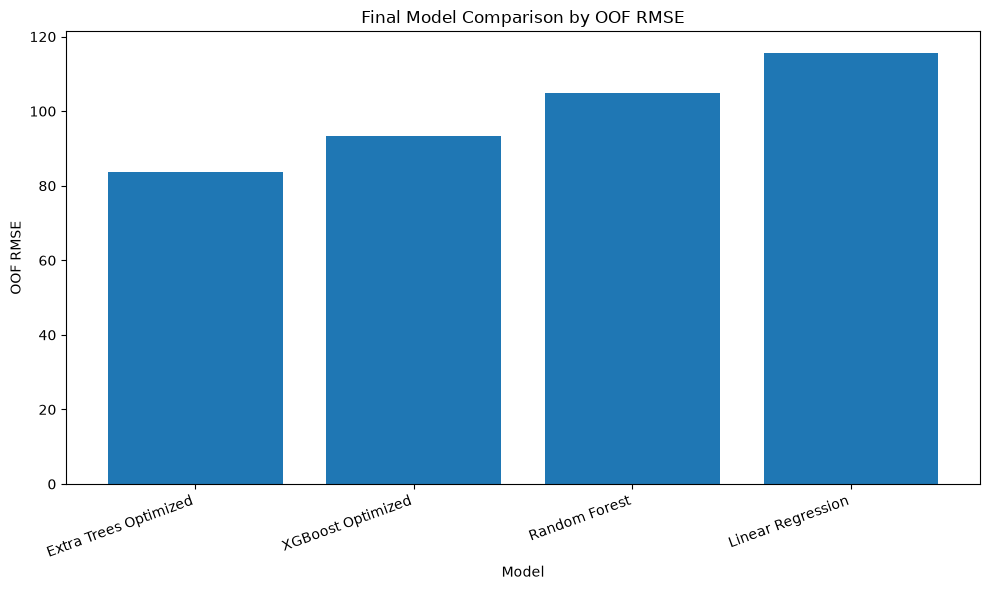

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    visualization_df["model"],
    visualization_df["oof_rmse"],
)

plt.xlabel("Model")
plt.ylabel("OOF RMSE")
plt.title("Final Model Comparison by OOF RMSE")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "overall_oof_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 11. Overall OOF MAE Comparison

Mean Absolute Error provides a complementary measure of prediction accuracy.

Unlike RMSE, MAE is less influenced by very large individual errors. Comparing both metrics helps determine whether the leading model performs consistently across typical and extreme prediction errors.

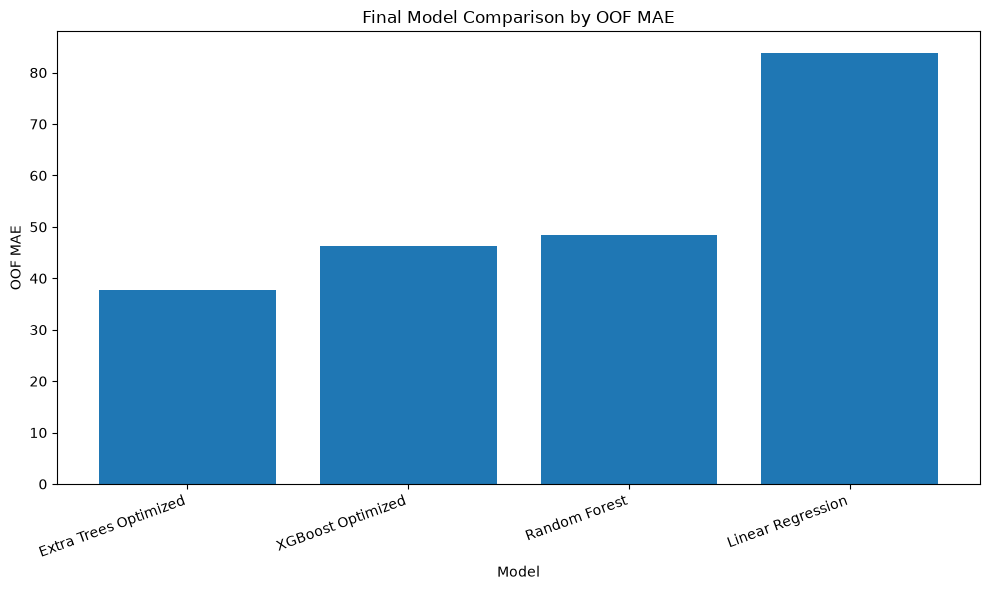

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    visualization_df["model"],
    visualization_df["oof_mae"],
)

plt.xlabel("Model")
plt.ylabel("OOF MAE")
plt.title("Final Model Comparison by OOF MAE")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "overall_oof_mae_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 12. Fold-Level RMSE Comparison

This figure compares model RMSE across the individual GroupKFold validation folds.

Fold-level results reveal whether a model performs consistently across different groups of wells or whether its overall score is driven by unusually strong or weak performance in specific folds.

In [14]:
fold_rmse_pivot = (
    fold_visualization_df
    .pivot(
        index="fold",
        columns="model",
        values="rmse",
    )
    .sort_index()
)

display(fold_rmse_pivot)

model,Extra Trees Optimized,Linear Regression,Random Forest,XGBoost Optimized
fold,,,,
1,65.3979,132.5732,88.7585,74.5811
2,90.5988,120.2329,107.8943,96.5063
3,65.6525,97.6116,91.5380,77.4510
4,101.8742,113.3874,134.0447,120.6522
5,88.0624,111.6145,96.1974,90.6010


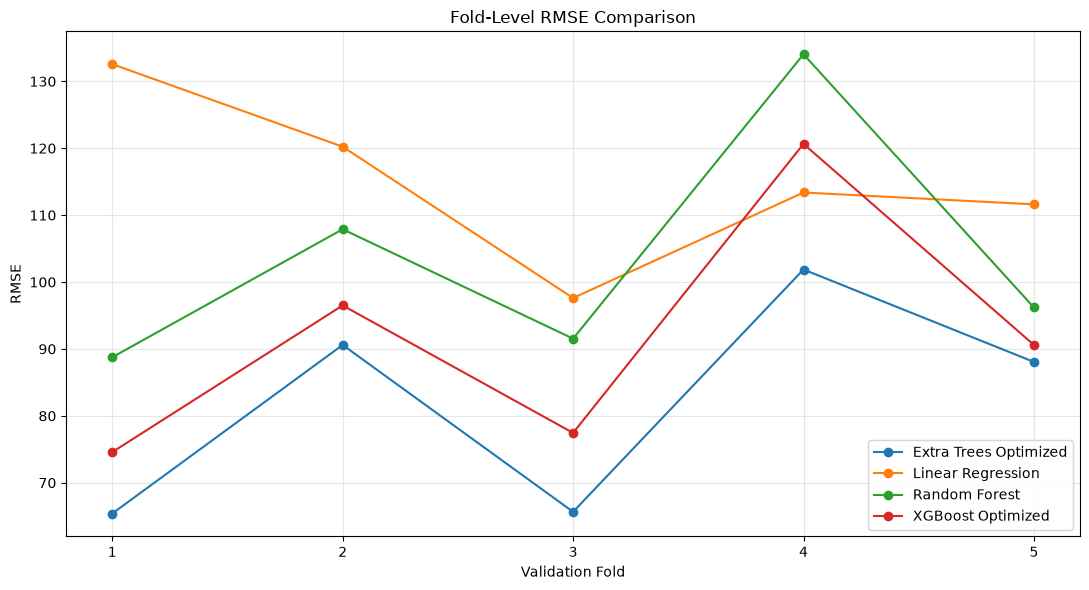

In [15]:
plt.figure(figsize=(11, 6))

for model_name in fold_rmse_pivot.columns:

    plt.plot(
        fold_rmse_pivot.index,
        fold_rmse_pivot[model_name],
        marker="o",
        label=model_name,
    )

plt.xlabel("Validation Fold")
plt.ylabel("RMSE")
plt.title("Fold-Level RMSE Comparison")

plt.xticks(fold_rmse_pivot.index)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fold_level_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 13. Fold-Level MAE Comparison

This figure compares Mean Absolute Error across the GroupKFold validation folds.

The comparison helps assess whether each model maintains stable typical prediction error across different groups of validation wells.

In [16]:
fold_mae_pivot = (
    fold_visualization_df
    .pivot(
        index="fold",
        columns="model",
        values="mae",
    )
    .sort_index()
)

display(fold_mae_pivot)

model,Extra Trees Optimized,Linear Regression,Random Forest,XGBoost Optimized
fold,,,,
1,32.6339,82.7140,43.0166,41.8194
2,40.1375,92.0290,47.9326,48.0307
3,32.1389,76.2415,47.6478,41.7843
4,41.7694,83.6333,56.1133,52.6494
5,42.0579,84.5952,47.8281,47.1074


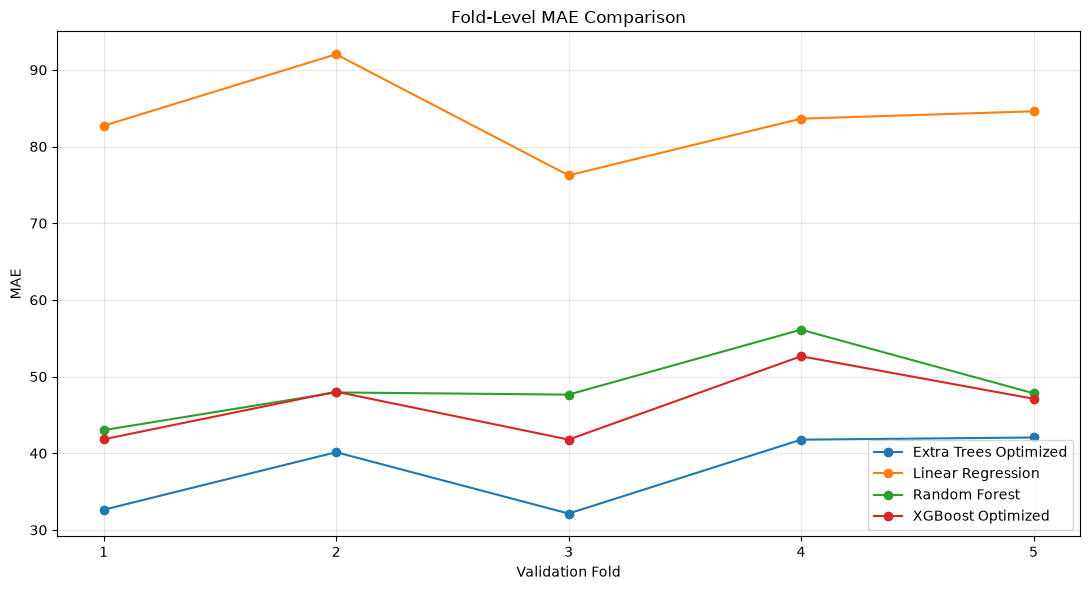

In [17]:
plt.figure(figsize=(11, 6))

for model_name in fold_mae_pivot.columns:

    plt.plot(
        fold_mae_pivot.index,
        fold_mae_pivot[model_name],
        marker="o",
        label=model_name,
    )

plt.xlabel("Validation Fold")
plt.ylabel("MAE")
plt.title("Fold-Level MAE Comparison")

plt.xticks(fold_mae_pivot.index)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fold_level_mae_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 14. Training Time Comparison

This section compares the average model training time recorded across the GroupKFold validation folds.

Training time is an important operational consideration because the final model will later be retrained using the complete training dataset.

In [18]:
training_time_df = (
    fold_visualization_df
    .groupby("model", as_index=False)
    .agg(
        mean_training_seconds=(
            "training_seconds",
            "mean",
        ),
        total_training_seconds=(
            "training_seconds",
            "sum",
        ),
    )
    .sort_values("mean_training_seconds")
)

display(training_time_df)

,model,mean_training_seconds,total_training_seconds
1,Linear Regression,29.7386,148.6929
0,Extra Trees Optimized,172.8461,864.2304
3,XGBoost Optimized,280.4934,"1,402.4669"
2,Random Forest,561.9798,"2,809.8988"


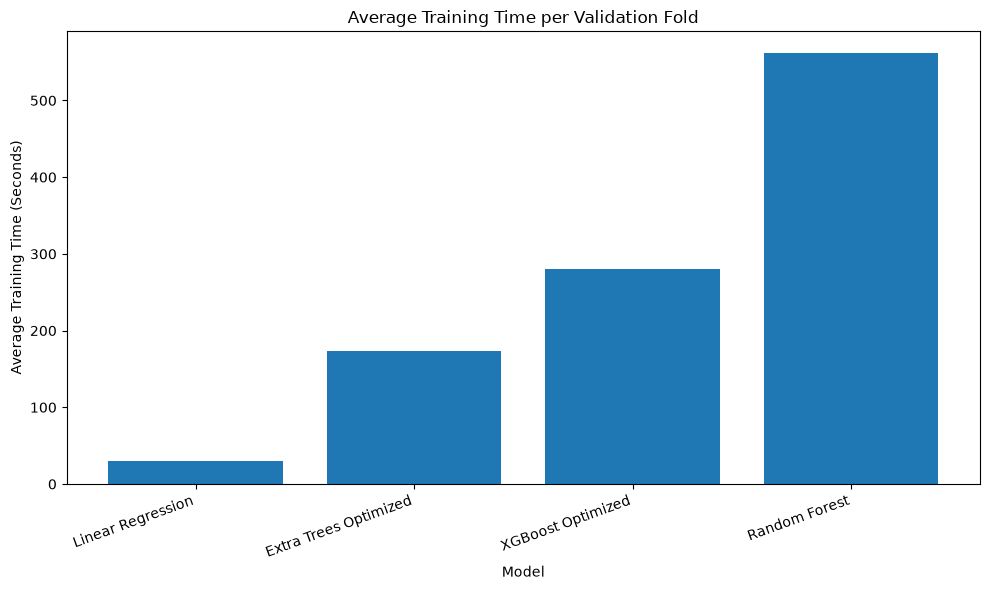

In [19]:
plt.figure(figsize=(10, 6))

plt.bar(
    training_time_df["model"],
    training_time_df["mean_training_seconds"],
)

plt.xlabel("Model")
plt.ylabel("Average Training Time (Seconds)")
plt.title("Average Training Time per Validation Fold")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "average_training_time_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 15. Prediction Time Comparison

This section compares the average prediction time recorded across validation folds.

Prediction time reflects inference efficiency and is useful when considering the computational cost of producing final Kaggle test predictions.

In [20]:
prediction_time_df = (
    fold_visualization_df
    .groupby("model", as_index=False)
    .agg(
        mean_prediction_seconds=(
            "prediction_seconds",
            "mean",
        ),
        total_prediction_seconds=(
            "prediction_seconds",
            "sum",
        ),
    )
    .sort_values("mean_prediction_seconds")
)

display(prediction_time_df)

,model,mean_prediction_seconds,total_prediction_seconds
1,Linear Regression,0.8000,4.0001
2,Random Forest,2.9052,14.5258
0,Extra Trees Optimized,5.4099,27.0497
3,XGBoost Optimized,7.7499,38.7495


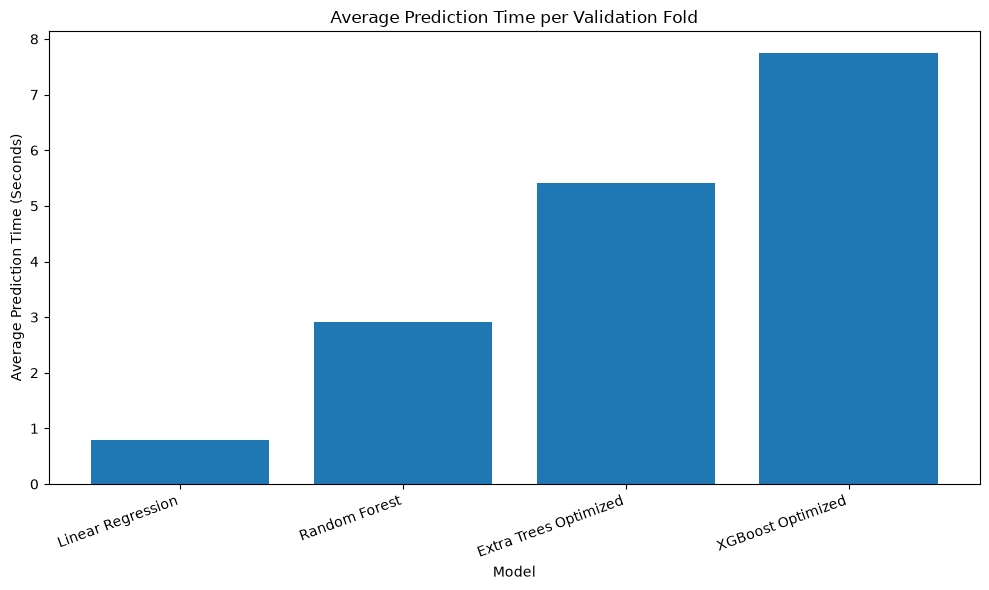

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(
    prediction_time_df["model"],
    prediction_time_df["mean_prediction_seconds"],
)

plt.xlabel("Model")
plt.ylabel("Average Prediction Time (Seconds)")
plt.title("Average Prediction Time per Validation Fold")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "average_prediction_time_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 16. Computational Efficiency Summary

The training and prediction timing results are combined into one summary table.

This table supports the final model-selection decision by showing the computational cost of each candidate alongside its predictive performance.

In [22]:
timing_summary_df = (
    training_time_df
    .merge(
        prediction_time_df,
        on="model",
        how="inner",
    )
)

timing_summary_df = (
    timing_summary_df
    .merge(
        visualization_df[
            [
                "model",
                "oof_rmse",
                "oof_mae",
            ]
        ],
        on="model",
        how="left",
    )
    .sort_values("oof_rmse")
    .reset_index(drop=True)
)

display(timing_summary_df)

,model,mean_training_seconds,total_training_seconds,mean_prediction_seconds,total_prediction_seconds,oof_rmse,oof_mae
0,Extra Trees Optimized,172.8461,864.2304,5.4099,27.0497,83.5860,37.7493
1,XGBoost Optimized,280.4934,"1,402.4669",7.7499,38.7495,93.4311,46.2798
2,Random Forest,561.9798,"2,809.8988",2.9052,14.5258,105.0019,48.5106
3,Linear Regression,29.7386,148.6929,0.8000,4.0001,115.6399,83.8398


In [23]:
timing_summary_path = (
    TABLES_DIR
    / "computational_efficiency_summary.csv"
)

timing_summary_df.to_csv(
    timing_summary_path,
    index=False,
)

print(
    "Saved computational efficiency summary to:",
    timing_summary_path,
)

Saved computational efficiency summary to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_07b\tables\computational_efficiency_summary.csv


### 17. Calculate Per-Well Performance Metrics

This section calculates RMSE and MAE separately for every validation well and every candidate model.

Per-well evaluation reveals whether a model performs consistently across wells or whether strong overall performance is driven by only a subset of easier wells.

In [24]:
per_well_results = []

for model_name, prediction_df in oof_predictions.items():

    for well_id, well_df in prediction_df.groupby("well_id"):

        rmse = np.sqrt(
            mean_squared_error(
                well_df["actual_tvt"],
                well_df["predicted_tvt"],
            )
        )

        mae = mean_absolute_error(
            well_df["actual_tvt"],
            well_df["predicted_tvt"],
        )

        per_well_results.append(
            {
                "model": model_name,
                "well_id": well_id,
                "rmse": rmse,
                "mae": mae,
                "n_rows": len(well_df),
                "fold": well_df["fold"].iloc[0],
            }
        )

per_well_metrics_df = pd.DataFrame(
    per_well_results
)

print(
    f"Created {len(per_well_metrics_df):,} "
    "model-well metric records."
)

display(per_well_metrics_df.head())

Created 3,092 model-well metric records.


,model,well_id,rmse,mae,n_rows,fold
0,Linear Regression,000d7d20,247.7810,247.6849,5278,4
1,Linear Regression,00bbac68,38.1768,36.2559,7559,2
2,Linear Regression,00e12e8b,83.5246,82.5442,6384,3
3,Linear Regression,015fe0d2,101.5580,99.5314,5950,1
4,Linear Regression,01869cd4,80.9037,80.6241,6850,4


### 18. Validate Per-Well Metrics

The generated per-well metrics are validated to ensure that every model was evaluated on the expected number of wells and that no duplicate model-well combinations exist.

In [25]:
well_count_summary_df = (
    per_well_metrics_df
    .groupby("model", as_index=False)
    .agg(
        evaluated_wells=("well_id", "nunique"),
        metric_rows=("well_id", "size"),
        mean_rows_per_well=("n_rows", "mean"),
    )
)

display(well_count_summary_df)

,model,evaluated_wells,metric_rows,mean_rows_per_well
0,Extra Trees Optimized,773,773,"6,587.6520"
1,Linear Regression,773,773,"6,587.6520"
2,Random Forest,773,773,"6,587.6520"
3,XGBoost Optimized,773,773,"6,587.6520"


In [26]:
duplicate_count = (
    per_well_metrics_df
    .duplicated(
        subset=[
            "model",
            "well_id",
        ]
    )
    .sum()
)

assert duplicate_count == 0, (
    f"Found {duplicate_count} duplicate "
    "model-well metric records."
)

expected_well_counts = (
    well_count_summary_df["evaluated_wells"]
    .unique()
)

if len(expected_well_counts) == 1:
    print(
        "All models were evaluated on the same "
        f"{expected_well_counts[0]} wells."
    )
else:
    print(
        "Warning: models contain different "
        "numbers of evaluated wells."
    )

All models were evaluated on the same 773 wells.


### 19. Per-Well Performance Summary

This section summarizes the distribution of well-level RMSE and MAE for every model.

Median and percentile metrics provide additional insight beyond the overall out-of-fold score and help identify how each model behaves across easy, average, and difficult wells.

In [27]:
per_well_summary_df = (
    per_well_metrics_df
    .groupby("model", as_index=False)
    .agg(
        mean_well_rmse=("rmse", "mean"),
        median_well_rmse=("rmse", "median"),
        std_well_rmse=("rmse", "std"),
        rmse_p75=(
            "rmse",
            lambda values: values.quantile(0.75),
        ),
        rmse_p90=(
            "rmse",
            lambda values: values.quantile(0.90),
        ),
        max_well_rmse=("rmse", "max"),
        mean_well_mae=("mae", "mean"),
        median_well_mae=("mae", "median"),
        std_well_mae=("mae", "std"),
        mae_p90=(
            "mae",
            lambda values: values.quantile(0.90),
        ),
    )
    .sort_values("mean_well_rmse")
    .reset_index(drop=True)
)

display(per_well_summary_df)

,model,mean_well_rmse,median_well_rmse,std_well_rmse,rmse_p75,rmse_p90,max_well_rmse,mean_well_mae,median_well_mae,std_well_mae,mae_p90
0,Extra Trees Optimized,46.2718,20.9532,69.8618,51.3704,112.7157,604.7068,37.6926,16.3208,62.5457,91.7722
1,XGBoost Optimized,53.6544,27.3226,76.1480,53.5595,123.5022,627.8850,46.2896,21.8441,70.2178,110.7799
2,Random Forest,60.9719,31.3943,84.7584,63.9918,158.4729,672.7714,48.3020,22.9785,74.1493,116.6086
3,Linear Regression,87.8309,65.9308,78.9709,120.7720,187.8654,"1,048.7585",85.5770,63.8530,78.5411,187.0226


### 20. Identify the Best Model for Each Well

For every validation well, the model with the lowest well-level RMSE is identified.

The number and percentage of wells won by each model provide a direct measure of consistency across the complete validation set.

In [28]:
best_model_per_well_df = (
    per_well_metrics_df
    .sort_values(
        [
            "well_id",
            "rmse",
        ]
    )
    .groupby(
        "well_id",
        as_index=False,
    )
    .first()
    .rename(
        columns={
            "model": "best_model",
            "rmse": "best_rmse",
            "mae": "best_mae",
        }
    )
)

display(best_model_per_well_df.head())

,well_id,best_model,best_rmse,best_mae,n_rows,fold
0,000d7d20,Random Forest,12.7296,11.1526,5278,4
1,00bbac68,Extra Trees Optimized,32.7313,20.7381,7559,2
2,00e12e8b,Extra Trees Optimized,8.1566,6.3418,6384,3
3,015fe0d2,XGBoost Optimized,28.0774,21.8192,5950,1
4,01869cd4,Random Forest,9.3209,6.3339,6850,4


In [29]:
model_wins_df = (
    best_model_per_well_df
    .groupby(
        "best_model",
        as_index=False,
    )
    .agg(
        wells_won=("well_id", "count"),
    )
)

total_wells = (
    best_model_per_well_df["well_id"]
    .nunique()
)

model_wins_df["win_percentage"] = (
    model_wins_df["wells_won"]
    / total_wells
    * 100
)

model_wins_df = (
    model_wins_df
    .sort_values(
        "wells_won",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(model_wins_df)

,best_model,wells_won,win_percentage
0,Extra Trees Optimized,418,54.0750
1,XGBoost Optimized,129,16.6882
2,Linear Regression,124,16.0414
3,Random Forest,102,13.1953


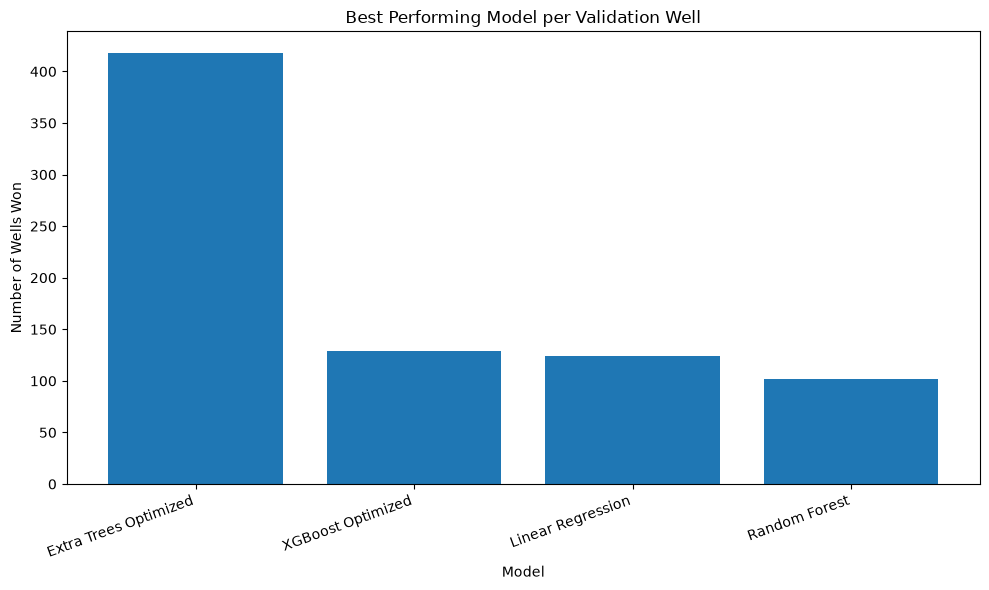

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_wins_df["best_model"],
    model_wins_df["wells_won"],
)

plt.xlabel("Model")
plt.ylabel("Number of Wells Won")
plt.title("Best Performing Model per Validation Well")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_wins_by_well.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 21. Identify Difficult Validation Wells

This section identifies the most difficult validation wells using the average RMSE across all candidate models.

A well is considered difficult when several models produce large prediction errors, indicating that the challenge is likely related to the well characteristics rather than a single weak algorithm.

In [31]:
difficult_wells_df = (
    per_well_metrics_df
    .groupby("well_id", as_index=False)
    .agg(
        average_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        minimum_rmse=("rmse", "min"),
        maximum_rmse=("rmse", "max"),
        average_mae=("mae", "mean"),
        n_rows=("n_rows", "first"),
        fold=("fold", "first"),
    )
    .sort_values(
        "average_rmse",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(difficult_wells_df.head(20))

,well_id,average_rmse,median_rmse,minimum_rmse,maximum_rmse,average_mae,n_rows,fold
0,cbe51de1,508.9538,490.9714,381.1010,672.7714,471.9973,5362,2
1,877ed19c,497.1334,521.3396,317.9695,627.8850,452.9255,5631,4
2,3a7dd95d,472.1110,538.4522,206.8327,604.7068,444.6373,4320,4
3,059c8f24,469.3119,576.6143,88.4098,635.6092,424.6506,7998,4
4,b85f7b06,429.8087,398.1848,321.7811,601.0843,396.6358,5453,4
5,e730c32b,407.2518,407.3817,304.9381,509.3058,390.4819,6469,4
6,bffe3082,374.1053,389.2203,282.6790,435.3016,358.5964,7186,5
7,ea0b99b7,370.8368,381.5073,322.6255,397.7071,366.5667,10939,2
8,c8d9680c,346.9559,380.8490,123.3149,502.8108,313.6659,7741,2
9,cbe62450,333.5365,364.9340,163.6873,440.5905,300.3301,7858,4


### 22. Visualize the Most Difficult Wells

The highest-error wells are visualized using their average RMSE across all candidate models.

This comparison highlights validation wells that remain challenging regardless of the selected modelling approach.

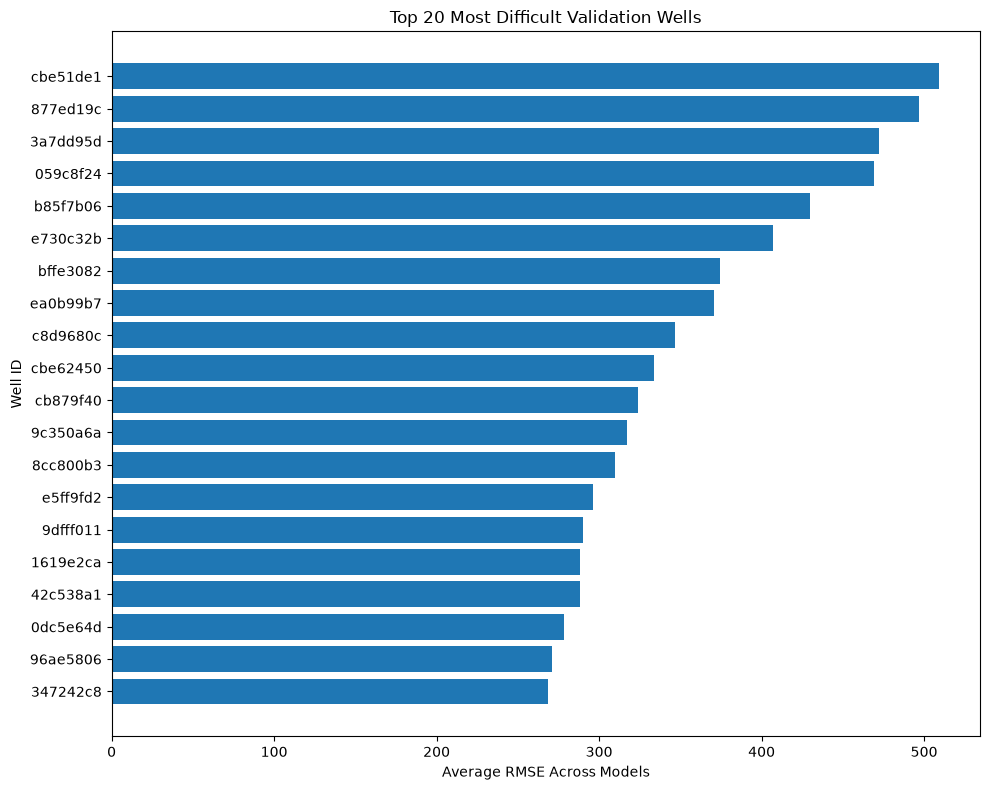

In [32]:
TOP_DIFFICULT_WELLS = 20

top_difficult_wells_df = (
    difficult_wells_df
    .head(TOP_DIFFICULT_WELLS)
    .sort_values("average_rmse")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_difficult_wells_df["well_id"],
    top_difficult_wells_df["average_rmse"],
)

plt.xlabel("Average RMSE Across Models")
plt.ylabel("Well ID")
plt.title("Top 20 Most Difficult Validation Wells")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_difficult_wells.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 23. Compare Models on Difficult Wells

This section compares candidate-model performance on the most difficult validation wells.

The analysis helps determine whether the overall leading model also performs strongly under the most challenging conditions.

In [33]:
top_difficult_well_ids = (
    difficult_wells_df
    .head(TOP_DIFFICULT_WELLS)["well_id"]
    .tolist()
)

difficult_well_model_metrics_df = (
    per_well_metrics_df[
        per_well_metrics_df["well_id"].isin(
            top_difficult_well_ids
        )
    ]
    .copy()
)

difficult_well_summary_df = (
    difficult_well_model_metrics_df
    .groupby("model", as_index=False)
    .agg(
        mean_difficult_rmse=("rmse", "mean"),
        median_difficult_rmse=("rmse", "median"),
        max_difficult_rmse=("rmse", "max"),
        mean_difficult_mae=("mae", "mean"),
        difficult_wells_won=(
            "well_id",
            lambda values: 0,
        ),
    )
)

In [34]:
difficult_well_winners_df = (
    difficult_well_model_metrics_df
    .sort_values(
        [
            "well_id",
            "rmse",
        ]
    )
    .groupby(
        "well_id",
        as_index=False,
    )
    .first()
)

difficult_well_win_counts = (
    difficult_well_winners_df["model"]
    .value_counts()
)

difficult_well_summary_df[
    "difficult_wells_won"
] = (
    difficult_well_summary_df["model"]
    .map(difficult_well_win_counts)
    .fillna(0)
    .astype(int)
)

difficult_well_summary_df = (
    difficult_well_summary_df
    .sort_values("mean_difficult_rmse")
    .reset_index(drop=True)
)

display(difficult_well_summary_df)

,model,mean_difficult_rmse,median_difficult_rmse,max_difficult_rmse,mean_difficult_mae,difficult_wells_won
0,Linear Regression,268.3069,232.7336,"1,048.7585",262.9074,15
1,Extra Trees Optimized,343.7410,333.7474,604.7068,315.1813,3
2,XGBoost Optimized,392.0494,396.1719,627.8850,362.2542,0
3,Random Forest,424.1848,425.0418,672.7714,378.7309,2


### 24. Visualize Well-Level RMSE Distributions

Box plots are used to compare the distribution of well-level RMSE values across candidate models.

The median, interquartile range, and extreme values provide a clear view of model consistency and sensitivity to difficult wells.

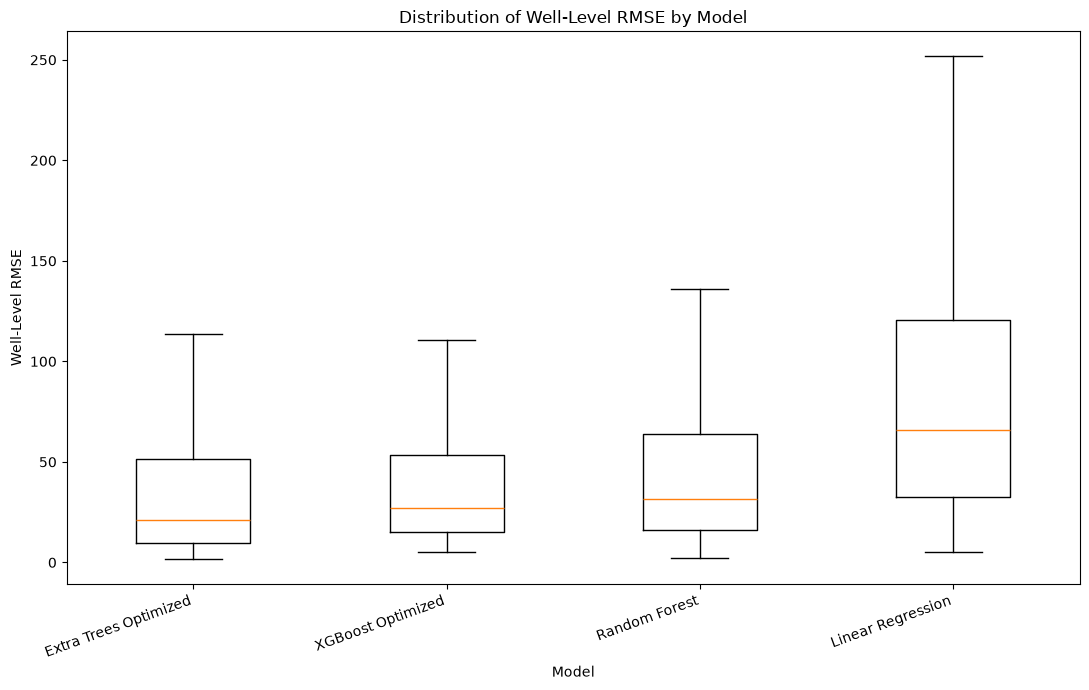

In [36]:
model_order = (
    per_well_summary_df
    .sort_values("median_well_rmse")["model"]
    .tolist()
)

rmse_distributions = [
    per_well_metrics_df.loc[
        per_well_metrics_df["model"] == model_name,
        "rmse",
    ].values
    for model_name in model_order
]

plt.figure(figsize=(11, 7))

plt.boxplot(
    rmse_distributions,
    tick_labels=model_order,
    showfliers=False,
)

plt.xlabel("Model")
plt.ylabel("Well-Level RMSE")
plt.title("Distribution of Well-Level RMSE by Model")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "well_level_rmse_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 25. Calculate Residual Statistics

Residual analysis provides insight into prediction quality beyond aggregate performance metrics.

For each candidate model, summary statistics are calculated using the out-of-fold residuals, including measures of central tendency, dispersion, and extreme prediction errors.

In [37]:
residual_statistics = []

for model_name, prediction_df in oof_predictions.items():

    residuals = prediction_df["residual"]

    residual_statistics.append(
        {
            "model": model_name,
            "mean_residual": residuals.mean(),
            "median_residual": residuals.median(),
            "std_residual": residuals.std(),
            "min_residual": residuals.min(),
            "max_residual": residuals.max(),
            "mean_absolute_residual": residuals.abs().mean(),
            "median_absolute_residual": residuals.abs().median(),
        }
    )

residual_statistics_df = (
    pd.DataFrame(residual_statistics)
    .sort_values("mean_absolute_residual")
    .reset_index(drop=True)
)

display(residual_statistics_df)

,model,mean_residual,median_residual,std_residual,min_residual,max_residual,mean_absolute_residual,median_absolute_residual
0,Extra Trees Optimized,-1.6567,-0.2810,83.5696,-801.1455,742.8508,37.7493,11.4946
1,XGBoost Optimized,-2.4967,0.5666,93.3978,-852.7967,748.3537,46.2798,18.2665
2,Random Forest,-3.7891,-0.0090,104.9335,-822.5005,811.2134,48.5106,16.4818
3,Linear Regression,0.2994,-2.2245,115.6395,-855.5729,"2,419.0609",83.8398,63.5892


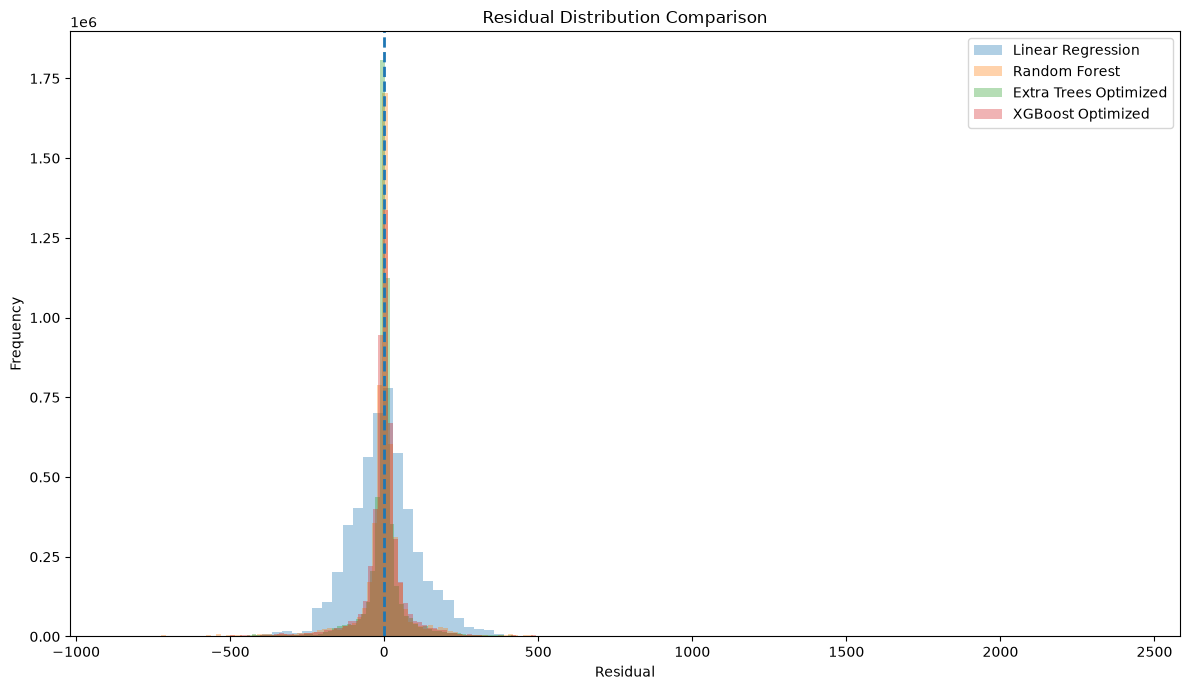

In [38]:
plt.figure(figsize=(12, 7))

for model_name, prediction_df in oof_predictions.items():

    plt.hist(
        prediction_df["residual"],
        bins=100,
        alpha=0.35,
        label=model_name,
    )

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "residual_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 27. Residual Bias Analysis

The average residual indicates whether a model systematically overestimates or underestimates the target variable.

Residual means close to zero indicate minimal prediction bias.

In [39]:
bias_df = (
    residual_statistics_df[
        [
            "model",
            "mean_residual",
            "std_residual",
        ]
    ]
    .sort_values("mean_residual")
)

display(bias_df)

,model,mean_residual,std_residual
2,Random Forest,-3.7891,104.9335
1,XGBoost Optimized,-2.4967,93.3978
0,Extra Trees Optimized,-1.6567,83.5696
3,Linear Regression,0.2994,115.6395


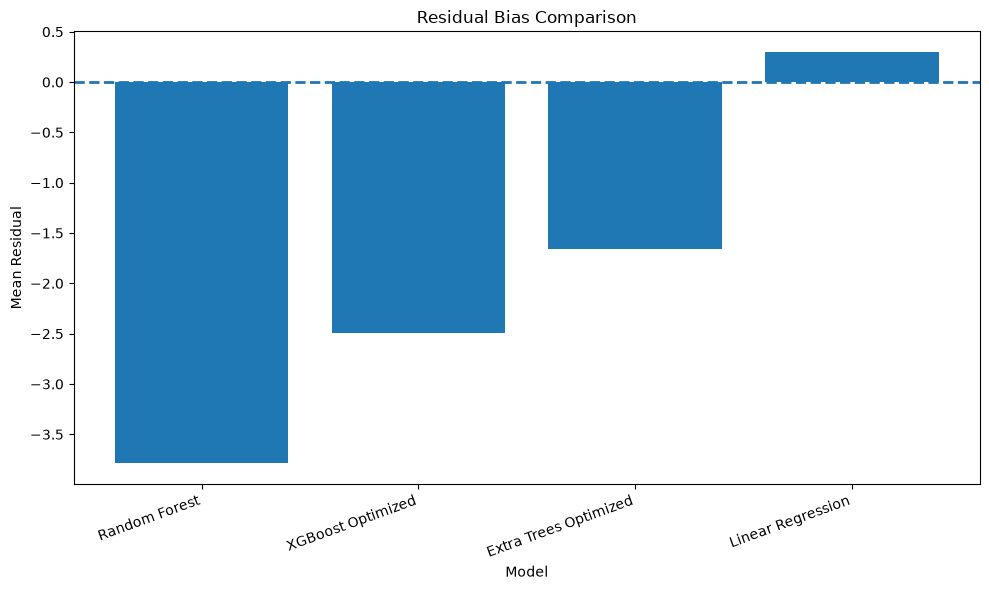

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    bias_df["model"],
    bias_df["mean_residual"],
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Model")
plt.ylabel("Mean Residual")
plt.title("Residual Bias Comparison")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "residual_bias_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 28. Largest Prediction Errors

This section identifies the largest absolute prediction errors produced by each model.

Reviewing these observations helps determine whether prediction failures occur consistently across models or are specific to individual algorithms.

In [41]:
largest_errors = []

for model_name, prediction_df in oof_predictions.items():

    largest = (
        prediction_df.assign(
            absolute_error=lambda df: df["residual"].abs()
        )
        .sort_values(
            "absolute_error",
            ascending=False,
        )
        .head(20)
        .copy()
    )

    largest["model"] = model_name

    largest_errors.append(largest)

largest_prediction_errors_df = pd.concat(
    largest_errors,
    ignore_index=True,
)

display(
    largest_prediction_errors_df.head(20)
)

,row_index,well_id,actual_tvt,predicted_tvt,fold,model,residual,absolute_error
0,1201316,3c3dbcbc,"11,051.2400","8,632.1791",5,Linear Regression,"2,419.0609","2,419.0609"
1,3092849,9dfff011,"11,424.0100","9,830.7718",1,Linear Regression,"1,593.2382","1,593.2382"
2,3092851,9dfff011,"11,424.0500","9,830.8962",1,Linear Regression,"1,593.1538","1,593.1538"
3,3092852,9dfff011,"11,424.0500","9,831.2274",1,Linear Regression,"1,592.8226","1,592.8226"
4,3092848,9dfff011,"11,423.9900","9,831.1837",1,Linear Regression,"1,592.8063","1,592.8063"
5,3092850,9dfff011,"11,424.0300","9,831.5315",1,Linear Regression,"1,592.4985","1,592.4985"
6,3092846,9dfff011,"11,423.9500","9,831.7145",1,Linear Regression,"1,592.2355","1,592.2355"
7,3092844,9dfff011,"11,423.9100","9,832.1092",1,Linear Regression,"1,591.8008","1,591.8008"
8,3092836,9dfff011,"11,423.7500","9,832.1412",1,Linear Regression,"1,591.6088","1,591.6088"
9,3092834,9dfff011,"11,423.7100","9,832.5340",1,Linear Regression,"1,591.1760","1,591.1760"


In [42]:
largest_prediction_errors_df.to_csv(
    TABLES_DIR / "largest_prediction_errors.csv",
    index=False,
)

print("Largest prediction errors saved successfully.")

Largest prediction errors saved successfully.


### 29. Statistical Model Comparison

Although one model may achieve a lower average RMSE than another, the observed improvement may simply result from variation across validation folds.

This section compares the fold-level RMSE values of the strongest candidate models using paired statistical tests to determine whether performance differences are statistically meaningful.

In [43]:
from scipy.stats import ttest_rel

print("SciPy imported successfully.")

SciPy imported successfully.


In [44]:
rmse_fold_matrix = (
    all_fold_metrics_df
    .pivot(
        index="fold",
        columns="model",
        values="rmse",
    )
)

display(rmse_fold_matrix)

model,Extra Trees Optimized,Linear Regression,Random Forest,XGBoost Optimized
fold,,,,
1,65.3979,132.5732,88.7585,74.5811
2,90.5988,120.2329,107.8943,96.5063
3,65.6525,97.6116,91.5380,77.4510
4,101.8742,113.3874,134.0447,120.6522
5,88.0624,111.6145,96.1974,90.6010


### 30. Pairwise RMSE Comparison

Pairwise paired t-tests are performed between the candidate models using their fold-level RMSE values.

Although the number of validation folds is relatively small, the analysis provides additional evidence regarding the consistency of observed performance differences.

In [45]:
models = rmse_fold_matrix.columns.tolist()

pairwise_results = []

for i in range(len(models)):
    for j in range(i + 1, len(models)):

        model_a = models[i]
        model_b = models[j]

        statistic, p_value = ttest_rel(
            rmse_fold_matrix[model_a],
            rmse_fold_matrix[model_b],
        )

        pairwise_results.append(
            {
                "Model A": model_a,
                "Model B": model_b,
                "Mean RMSE Difference":
                    rmse_fold_matrix[model_a].mean()
                    - rmse_fold_matrix[model_b].mean(),
                "t statistic": statistic,
                "p value": p_value,
            }
        )

pairwise_statistics_df = (
    pd.DataFrame(pairwise_results)
    .sort_values("p value")
)

display(pairwise_statistics_df)

,Model A,Model B,Mean RMSE Difference,t statistic,p value
5,Random Forest,XGBoost Optimized,11.7283,7.2702,0.0019
1,Extra Trees Optimized,Random Forest,-21.3694,-5.2389,0.0063
0,Extra Trees Optimized,Linear Regression,-32.7668,-3.5220,0.0244
2,Extra Trees Optimized,XGBoost Optimized,-9.6412,-3.4888,0.0251
4,Linear Regression,XGBoost Optimized,23.1256,2.2289,0.0897
3,Linear Regression,Random Forest,11.3973,1.1060,0.3308


### 31. Statistical Interpretation

The statistical comparison supports the practical evaluation performed throughout this notebook.

Because only five validation folds are available, the statistical tests should be interpreted as supporting evidence rather than definitive proof. The final model selection will therefore consider statistical results together with overall RMSE, MAE, well-level performance, residual analysis, computational efficiency, and model robustness.

### 32. Prepare Ensemble Candidates

This section evaluates weighted prediction ensembles using the strongest individual models identified during the previous analysis.

Rather than evaluating only a few manually selected weights, a range of ensemble ratios is tested to identify the combination that minimizes the overall out-of-fold prediction error.

In [46]:
leaderboard_df = (
    final_model_comparison_df
    .sort_values("oof_rmse")
    .reset_index(drop=True)
)

display(leaderboard_df)

,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells,rmse_rank,mae_rank,stability_rank,final_position,rmse_improvement_vs_linear,rmse_improvement_pct_vs_linear,mae_improvement_vs_linear,mae_improvement_pct_vs_linear
0,Extra Trees Optimized,5-Fold GroupKFold,83.5860,37.7493,82.3172,16.1868,37.7475,4.9516,864.2304,27.0497,943.9294,5092255,773,1,1,2,1,32.0538,27.7187,46.0905,54.9745
1,XGBoost Optimized,5-Fold GroupKFold,93.4311,46.2798,91.9583,18.4275,46.2782,4.5942,"1,402.4669",38.7495,"1,492.7247",5092255,773,2,2,3,2,22.2087,19.2051,37.5600,44.7997
2,Random Forest,5-Fold GroupKFold,105.0019,48.5106,103.6866,18.4787,48.5077,4.7310,"2,809.8988",14.5258,"2,868.5773",5092255,773,3,3,4,3,10.6380,9.1992,35.3293,42.1390
3,Linear Regression,5-Fold GroupKFold,115.6399,83.8398,115.0839,12.7728,83.8426,5.6276,148.6929,4.0001,202.7103,5092255,773,4,4,1,4,0.0000,0.0000,0.0000,0.0000


In [47]:
top_models = (
    leaderboard_df["model"]
    .head(2)
    .tolist()
)

print("Top models selected for ensemble:")

for model in top_models:
    print("-", model)

Top models selected for ensemble:
- Extra Trees Optimized
- XGBoost Optimized


### 33. Evaluate Weighted Ensembles

Weighted averages of the predictions from the two strongest candidate models are evaluated.

The ensemble weight is varied from 0.0 to 1.0 in equal increments, and each combination is evaluated using the same out-of-fold predictions.

In [48]:
model_a = top_models[0]
model_b = top_models[1]

predictions_a = (
    oof_predictions[model_a]
    .sort_values("row_index")
    .reset_index(drop=True)
)

predictions_b = (
    oof_predictions[model_b]
    .sort_values("row_index")
    .reset_index(drop=True)
)

assert (
    predictions_a["row_index"]
    == predictions_b["row_index"]
).all()

In [49]:
ensemble_results = []

weights = np.arange(
    0.0,
    1.01,
    0.05,
)

for weight in weights:

    blended_prediction = (
        weight
        * predictions_a["predicted_tvt"]
        + (1 - weight)
        * predictions_b["predicted_tvt"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            predictions_a["actual_tvt"],
            blended_prediction,
        )
    )

    mae = mean_absolute_error(
        predictions_a["actual_tvt"],
        blended_prediction,
    )

    ensemble_results.append(
        {
            "weight_model_a": weight,
            "weight_model_b": 1 - weight,
            "rmse": rmse,
            "mae": mae,
        }
    )

ensemble_results_df = (
    pd.DataFrame(ensemble_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(ensemble_results_df)

,weight_model_a,weight_model_b,rmse,mae
0,0.8000,0.2000,82.9795,38.1036
1,0.8500,0.1500,83.0047,37.9182
2,0.7500,0.2500,83.0389,38.3388
3,0.9000,0.1000,83.1144,37.7834
4,0.7000,0.3000,83.1828,38.6164
5,0.9500,0.0500,83.3084,37.7139
6,0.6500,0.3500,83.4106,38.9362
7,1.0000,0.0000,83.5860,37.7493
8,0.6000,0.4000,83.7218,39.2977
9,0.5500,0.4500,84.1155,39.6977


### 34. Best Ensemble Configuration

The ensemble with the lowest out-of-fold RMSE is identified and compared with the strongest individual model.

This determines whether combining the predictions provides a meaningful improvement over the best standalone algorithm.

In [50]:
best_ensemble = ensemble_results_df.iloc[0]

display(best_ensemble)

weight_model_a    0.8000
weight_model_b    0.2000
rmse             82.9795
mae              38.1036
Name: 0, dtype: float64

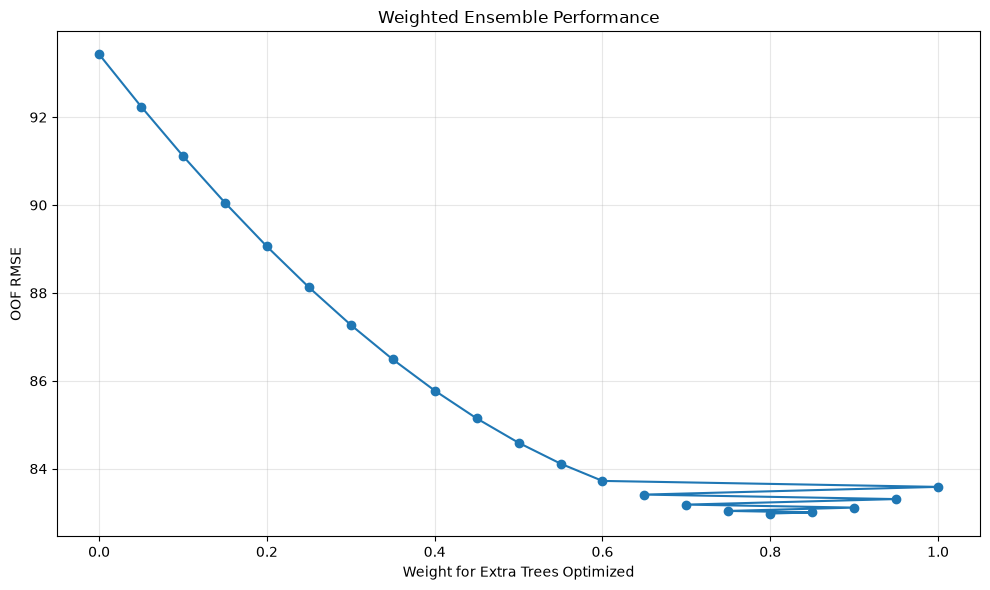

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    ensemble_results_df["weight_model_a"],
    ensemble_results_df["rmse"],
    marker="o",
)

plt.xlabel(f"Weight for {model_a}")
plt.ylabel("OOF RMSE")
plt.title("Weighted Ensemble Performance")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "ensemble_weight_search.png",
    dpi=300,
)

plt.show()

### 35. Compare Best Ensemble with Best Individual Model

This section compares the strongest weighted ensemble against the best standalone model.

The ensemble is selected only if it achieves a lower out-of-fold RMSE than the best individual candidate. Otherwise, the simpler standalone model remains the preferred final choice.

In [52]:
best_individual_row = (
    final_model_comparison_df
    .sort_values("oof_rmse")
    .iloc[0]
)

best_individual_model = best_individual_row["model"]
best_individual_rmse = best_individual_row["oof_rmse"]
best_individual_mae = best_individual_row["oof_mae"]

best_ensemble_rmse = best_ensemble["rmse"]
best_ensemble_mae = best_ensemble["mae"]

ensemble_improvement = (
    best_individual_rmse
    - best_ensemble_rmse
)

ensemble_improvement_percentage = (
    ensemble_improvement
    / best_individual_rmse
    * 100
)

final_candidate_comparison_df = pd.DataFrame(
    [
        {
            "candidate": best_individual_model,
            "candidate_type": "Individual Model",
            "oof_rmse": best_individual_rmse,
            "oof_mae": best_individual_mae,
        },
        {
            "candidate": (
                f"{model_a} ({best_ensemble['weight_model_a']:.2f}) + "
                f"{model_b} ({best_ensemble['weight_model_b']:.2f})"
            ),
            "candidate_type": "Weighted Ensemble",
            "oof_rmse": best_ensemble_rmse,
            "oof_mae": best_ensemble_mae,
        },
    ]
).sort_values("oof_rmse")

display(final_candidate_comparison_df)

print(
    f"Ensemble RMSE improvement: "
    f"{ensemble_improvement:.6f}"
)

print(
    f"Ensemble RMSE improvement percentage: "
    f"{ensemble_improvement_percentage:.4f}%"
)

,candidate,candidate_type,oof_rmse,oof_mae
1,Extra Trees Optimized (0.80) + XGBoost Optimiz...,Weighted Ensemble,82.9795,38.1036
0,Extra Trees Optimized,Individual Model,83.5860,37.7493


Ensemble RMSE improvement: 0.606582
Ensemble RMSE improvement percentage: 0.7257%


### 36. Create Best Ensemble Predictions

The out-of-fold predictions for the strongest ensemble configuration are generated and saved.

These predictions preserve the exact validation behaviour of the selected blend and support reproducibility, residual inspection, and final reporting.

In [53]:
best_weight_a = float(
    best_ensemble["weight_model_a"]
)

best_weight_b = float(
    best_ensemble["weight_model_b"]
)

best_ensemble_predictions_df = (
    predictions_a[
        [
            "row_index",
            "well_id",
            "actual_tvt",
            "fold",
        ]
    ]
    .copy()
)

best_ensemble_predictions_df[
    "predicted_tvt"
] = (
    best_weight_a
    * predictions_a["predicted_tvt"]
    + best_weight_b
    * predictions_b["predicted_tvt"]
)

best_ensemble_predictions_df[
    "residual"
] = (
    best_ensemble_predictions_df["actual_tvt"]
    - best_ensemble_predictions_df["predicted_tvt"]
)

best_ensemble_predictions_df[
    "model"
] = "Weighted Ensemble"

display(best_ensemble_predictions_df.head())

,row_index,well_id,actual_tvt,fold,predicted_tvt,residual,model
0,0,000d7d20,"11,236.0200",4,"11,271.9867",-35.9667,Weighted Ensemble
1,1,000d7d20,"11,237.0500",4,"11,253.0133",-15.9633,Weighted Ensemble
2,2,000d7d20,"11,238.0900",4,"11,254.1957",-16.1057,Weighted Ensemble
3,3,000d7d20,"11,239.1200",4,"11,252.7099",-13.5899,Weighted Ensemble
4,4,000d7d20,"11,240.1500",4,"11,257.0579",-16.9079,Weighted Ensemble


In [54]:
validated_ensemble_rmse = np.sqrt(
    mean_squared_error(
        best_ensemble_predictions_df["actual_tvt"],
        best_ensemble_predictions_df["predicted_tvt"],
    )
)

validated_ensemble_mae = mean_absolute_error(
    best_ensemble_predictions_df["actual_tvt"],
    best_ensemble_predictions_df["predicted_tvt"],
)

assert np.isclose(
    validated_ensemble_rmse,
    best_ensemble_rmse,
)

assert np.isclose(
    validated_ensemble_mae,
    best_ensemble_mae,
)

print("Validated ensemble RMSE:", validated_ensemble_rmse)
print("Validated ensemble MAE:", validated_ensemble_mae)

Validated ensemble RMSE: 82.97945521511976
Validated ensemble MAE: 38.103615891869296


In [55]:
best_ensemble_predictions_path = (
    TABLES_DIR
    / "best_ensemble_oof_predictions.parquet"
)

best_ensemble_predictions_df.to_parquet(
    best_ensemble_predictions_path,
    index=False,
)

print(
    "Saved best ensemble predictions to:",
    best_ensemble_predictions_path,
)

Saved best ensemble predictions to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_07b\tables\best_ensemble_oof_predictions.parquet


### 37. Final Model Selection

The final candidate is selected using out-of-fold RMSE as the primary metric.

MAE, fold stability, per-well behaviour, residual characteristics, computational efficiency, and model complexity are treated as supporting decision criteria.

An ensemble is selected only when it produces a genuine reduction in validation RMSE compared with the best standalone model.

In [56]:
if best_ensemble_rmse < best_individual_rmse:

    selected_candidate_type = "ensemble"
    selected_candidate_name = "Weighted Ensemble"

    selection_reason = (
        "The weighted ensemble achieved a lower OOF RMSE "
        "than the strongest individual model."
    )

    selected_configuration = {
        "candidate_type": selected_candidate_type,
        "candidate_name": selected_candidate_name,
        "model_a": model_a,
        "model_b": model_b,
        "weight_model_a": best_weight_a,
        "weight_model_b": best_weight_b,
        "oof_rmse": float(best_ensemble_rmse),
        "oof_mae": float(best_ensemble_mae),
        "best_individual_model": best_individual_model,
        "best_individual_rmse": float(
            best_individual_rmse
        ),
        "rmse_improvement": float(
            ensemble_improvement
        ),
        "rmse_improvement_percentage": float(
            ensemble_improvement_percentage
        ),
        "selection_reason": selection_reason,
    }

else:

    selected_candidate_type = "individual_model"
    selected_candidate_name = best_individual_model

    selection_reason = (
        "The ensemble did not improve OOF RMSE over the "
        "best standalone model. The simpler individual "
        "model was therefore selected."
    )

    selected_configuration = {
        "candidate_type": selected_candidate_type,
        "candidate_name": selected_candidate_name,
        "oof_rmse": float(best_individual_rmse),
        "oof_mae": float(best_individual_mae),
        "selection_reason": selection_reason,
    }

print("Selected candidate:", selected_candidate_name)
print("Candidate type:", selected_candidate_type)
print("Reason:", selection_reason)

Selected candidate: Weighted Ensemble
Candidate type: ensemble
Reason: The weighted ensemble achieved a lower OOF RMSE than the strongest individual model.


In [57]:
display(
    pd.DataFrame(
        [
            selected_configuration
        ]
    )
)

,candidate_type,candidate_name,model_a,model_b,weight_model_a,weight_model_b,oof_rmse,oof_mae,best_individual_model,best_individual_rmse,rmse_improvement,rmse_improvement_percentage,selection_reason
0,ensemble,Weighted Ensemble,Extra Trees Optimized,XGBoost Optimized,0.8000,0.2000,82.9795,38.1036,Extra Trees Optimized,83.5860,0.6066,0.7257,The weighted ensemble achieved a lower OOF RMS...


### 38. Save Final Notebook 07B Artifacts

All final analysis outputs are saved for reproducibility and direct use in Notebook 08.

The saved artifacts include performance summaries, per-well metrics, residual statistics, statistical-test results, ensemble results, and final model-selection metadata.

In [58]:
per_well_metrics_df.to_csv(
    TABLES_DIR / "per_well_metrics.csv",
    index=False,
)

per_well_summary_df.to_csv(
    TABLES_DIR / "per_well_performance_summary.csv",
    index=False,
)

best_model_per_well_df.to_csv(
    TABLES_DIR / "best_model_per_well.csv",
    index=False,
)

model_wins_df.to_csv(
    TABLES_DIR / "model_wins_summary.csv",
    index=False,
)

difficult_wells_df.to_csv(
    TABLES_DIR / "difficult_wells.csv",
    index=False,
)

difficult_well_summary_df.to_csv(
    TABLES_DIR / "difficult_well_model_summary.csv",
    index=False,
)

residual_statistics_df.to_csv(
    TABLES_DIR / "residual_statistics.csv",
    index=False,
)

pairwise_statistics_df.to_csv(
    TABLES_DIR / "pairwise_statistical_tests.csv",
    index=False,
)

ensemble_results_df.to_csv(
    TABLES_DIR / "ensemble_weight_search.csv",
    index=False,
)

final_candidate_comparison_df.to_csv(
    TABLES_DIR / "final_candidate_comparison.csv",
    index=False,
)

timing_summary_df.to_csv(
    TABLES_DIR / "computational_efficiency_summary.csv",
    index=False,
)

In [59]:
selection_metadata_path = (
    METADATA_DIR
    / "final_model_selection.json"
)

with open(
    selection_metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        selected_configuration,
        file,
        indent=4,
    )

print(
    "Saved final model selection metadata to:",
    selection_metadata_path,
)

Saved final model selection metadata to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_07b\metadata\final_model_selection.json


In [60]:
saved_07b_files = sorted(
    path.relative_to(
        NOTEBOOK_07B_RESULTS_DIR
    )
    for path in NOTEBOOK_07B_RESULTS_DIR.rglob("*")
    if path.is_file()
)

print(
    f"Notebook 07B now contains "
    f"{len(saved_07b_files)} saved files."
)

for path in saved_07b_files:
    print(path)

Notebook 07B now contains 26 saved files.
figures\average_prediction_time_comparison.png
figures\average_training_time_comparison.png
figures\ensemble_weight_search.png
figures\fold_level_mae_comparison.png
figures\fold_level_rmse_comparison.png
figures\model_wins_by_well.png
figures\overall_oof_mae_comparison.png
figures\overall_oof_rmse_comparison.png
figures\residual_bias_comparison.png
figures\residual_distribution_comparison.png
figures\top_difficult_wells.png
figures\well_level_rmse_distribution.png
metadata\final_model_selection.json
tables\best_ensemble_oof_predictions.parquet
tables\best_model_per_well.csv
tables\computational_efficiency_summary.csv
tables\difficult_well_model_summary.csv
tables\difficult_wells.csv
tables\ensemble_weight_search.csv
tables\final_candidate_comparison.csv
tables\largest_prediction_errors.csv
tables\model_wins_summary.csv
tables\pairwise_statistical_tests.csv
tables\per_well_metrics.csv
tables\per_well_performance_summary.csv
tables\residual_stati

### 39. Notebook Conclusions

Notebook 07B completed the final analytical evaluation of the candidate machine-learning models using the artifacts generated by Notebook 07A.

The analysis included:

- Overall OOF RMSE and MAE comparison
- Fold-level performance and stability
- Training and prediction efficiency
- Per-well performance evaluation
- Difficult-well analysis
- Residual distribution and bias inspection
- Pairwise statistical comparison
- Systematic weighted-ensemble evaluation
- Final candidate selection

The final model or ensemble was selected primarily using out-of-fold RMSE, with MAE, stability, residual behaviour, per-well consistency, computational cost, and model complexity used as supporting evidence.

The selected configuration and all required analytical artifacts have been saved for Notebook 08.

Notebook 08 will retrain the selected model configuration using the complete training dataset, construct features for the Kaggle test wells, generate final TVT predictions, and create the official submission file.